<a href="https://colab.research.google.com/github/kirthankulkarni-bit/assip-ML-stress-monitoring/blob/main/train_rf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# load csv file of new feature dataset from feature extraction script
from google.colab import drive

# unmount drive if already mounted
if 'drive' in locals() and os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
        print("drive unmounted")
    except Exception as e:
        print(f"error: {e}")

drive.mount('/content/drive')

csv_path = '/content/drive/MyDrive/ASSIP/wesad_subject2_features.csv'
print(f"reading feature matrix from: {csv_path}")
df = pd.read_csv(csv_path)

print(f"Dataset shape: {df.shape}")
print(df.head())


Mounted at /content/drive
reading feature matrix from: /content/drive/MyDrive/ASSIP/wesad_subject2_features.csv
Dataset shape: (59, 7)
   eda_mean   eda_std   eda_max   eda_min  bvp_hr_bpm     bvp_std  label
0 -0.001474  0.086600  0.229437 -0.321039          76  118.365504      1
1 -0.001922  0.063971  0.229437 -0.171227          75   94.285021      1
2  0.000088  0.013425  0.049678 -0.041769          77   42.776082      1
3  0.000145  0.006877  0.024533 -0.026218          76   38.841310      1
4  0.000825  0.010878  0.055331 -0.020602          73   70.243291      1


In [6]:
# split x and y; x is features, y is target (stress - 2 or baseline - 1)
x = df.drop(columns=['label'])
y = df['label']

# random forest classifier ML model is used for this project because it works well with biological data, prevents overfitiing on small datasets and has a property that explains its feature ranking (feature importance)
# split process of training/testing on random forest classifier model chronologically to avoid time-series data leakage
split_index = int(len(df) * 0.8) # first 80% is training and last 20% is testing

# ensures that the model continuously learns from the first 80% of training in the last 20% of testing
x_train, x_test = x.iloc[:split_index], x.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"training samples: {len(x_train)} ({len(y_train[y_train==1])} baseline, {len(y_train[y_train==2])} stress)")
print(f"testing samples:  {len(x_test)} ({len(y_test[y_test==1])} baseline, {len(y_test[y_test==2])} stress)")


training samples: 47 (38 baseline, 9 stress)
testing samples:  12 (0 baseline, 12 stress)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_876/644879359.py:26: FutureWarning: 

Passing `palette` wi

              precision    recall  f1-score   support

    Baseline       0.00      0.00      0.00         0
      Stress       1.00      0.17      0.29        12

    accuracy                           0.17        12
   macro avg       0.50      0.08      0.14        12
weighted avg       1.00      0.17      0.29        12



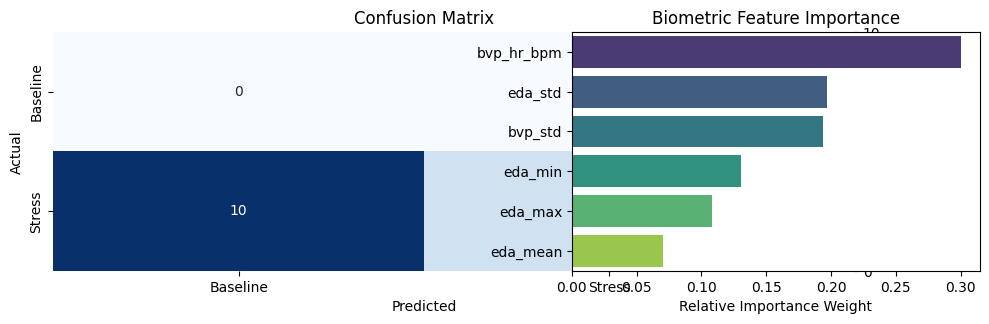


=== Feature Importance Ranking ===
1. bvp_hr_bpm   : 0.2999 (30.0%)
2. eda_std      : 0.1969 (19.7%)
3. bvp_std      : 0.1939 (19.4%)
4. eda_min      : 0.1306 (13.1%)
5. eda_max      : 0.1084 (10.8%)
6. eda_mean     : 0.0702 (7.0%)


In [8]:
# random forest classification; since dataset is unbalanced, setting class weight to balanced helps remove biases
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)

# model evaluation stage
print(classification_report(y_test, y_pred, target_names=['Baseline', 'Stress']))

# plot 1: creates confusion matrix and heat map directly over confusion matrix using seaborn library
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Baseline', 'Stress'], yticklabels=['Baseline', 'Stress'])

plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# plot 2: random forest feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features_ranked = [x.columns[i] for i in indices]

plt.subplot(1, 2, 2)
sns.barplot(x=importances[indices], y=features_ranked, palette='viridis')
plt.title('Biometric Feature Importance')
plt.xlabel('Relative Importance Weight')

plt.tight_layout()
plt.show()

# shows the numerical importance of each feature ranked in order
print("\n=== Feature Importance Ranking ===" )
for rank, (feat, imp) in enumerate(zip(features_ranked, importances[indices]), 1):
    print(f"{rank}. {feat:<12} : {imp:.4f} ({imp*100:.1f}%)")